<a href="https://colab.research.google.com/github/Yousra-belg/blackscholes-jumps-deeplearning/blob/main/Copie_de_pinn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PINN — Black-Scholes avec Sauts
**Membre 2** — Architecture du réseau de neurones

In [28]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Appareil utilisé :', device)

Appareil utilisé : cuda


In [29]:
#ÉTAPE 1 — Installer et importer les bibliothèques
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Appareil utilisé :", device)

Appareil utilisé : cuda


In [30]:
# Paramètres du modèle (cas n=1 saut, Call européen)
r     = 0.05   # taux sans risque
sigma = 0.20   # volatilité
alpha = 0.10   # amplitude du saut
lam   = 0.50   # intensité risque-neutre λ̃
K     = 100.0  # strike
T     = 1.0    # maturité

In [31]:
#Construire le réseau de neurones: Le réseau prend (t, x) en entrée et retourne V̂(t, x) en sortie.
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),    # entrée : (t, x)
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)     # sortie : V(t,x)
        )

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        return self.net(inp)

model = PINN().to(device)
print(model)

PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [32]:
def sample_points(N_interior, N_terminal):
    t_int = torch.rand(N_interior, 1) * T
    # x entre 20 et 300
    x_int = torch.rand(N_interior, 1) * 280 + 20

    # Points terminaux : t = T, x ∈ [20, 300]
    t_ter = torch.ones(N_terminal, 1) * T
    x_ter = torch.rand(N_terminal, 1) * 280 + 20

    return (t_int.to(device).requires_grad_(True),
            x_int.to(device).requires_grad_(True),
            t_ter.to(device),
            x_ter.to(device))

In [33]:
def loss_fn(model, t_int, x_int, t_ter, x_ter):

    #  PARTIE 1 : résidu EIDP
    V = model(t_int, x_int)
    dV_dt = torch.autograd.grad(V, t_int,
                grad_outputs=torch.ones_like(V),
                create_graph=True)[0]

    dV_dx = torch.autograd.grad(V, x_int,
                grad_outputs=torch.ones_like(V),
                create_graph=True)[0]

    d2V_dx2 = torch.autograd.grad(dV_dx, x_int,
                grad_outputs=torch.ones_like(dV_dx),
                create_graph=True)[0]

    # Terme de saut : V(t, x*(1+alpha))
    x_jump = x_int * (1 + alpha)
    V_jump = model(t_int, x_jump)

    # Résidu de l'EIDP
    residu = (-r * V
              + dV_dt
              + r * x_int * dV_dx
              + 0.5 * sigma**2 * x_int**2 * d2V_dx2
              + lam * (V_jump - V - x_int * alpha * dV_dx))

    loss_eidp = torch.mean(residu**2)

    # ── PARTIE 2 : condition terminale φ(x) = (x-K)⁺
    V_ter = model(t_ter, x_ter)
    payoff = torch.clamp(x_ter - K, min=0)
    loss_terminal = torch.mean((V_ter - payoff)**2)

    return loss_eidp + loss_terminal, loss_eidp, loss_terminal

In [34]:
#Entraîner le modèle
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

losses = []

for epoch in range(30000):
    t_int, x_int, t_ter, x_ter = sample_points(2000, 500)

    optimizer.zero_grad()
    loss, l_eidp, l_ter = loss_fn(model, t_int, x_int, t_ter, x_ter)
    loss.backward()
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss totale: {loss.item():.6f} "
              f"| EIDP: {l_eidp.item():.6f} | Terminal: {l_ter.item():.6f}")

Epoch     0 | Loss totale: 8718.729492 | EIDP: 0.000060 | Terminal: 8718.729492
Epoch   500 | Loss totale: 5681.566895 | EIDP: 2.823138 | Terminal: 5678.743652
Epoch  1000 | Loss totale: 4931.935547 | EIDP: 7.214361 | Terminal: 4924.721191
Epoch  1500 | Loss totale: 4256.250488 | EIDP: 10.585276 | Terminal: 4245.665039
Epoch  2000 | Loss totale: 4240.674805 | EIDP: 12.091301 | Terminal: 4228.583496
Epoch  2500 | Loss totale: 4318.939453 | EIDP: 12.422742 | Terminal: 4306.516602
Epoch  3000 | Loss totale: 4575.281250 | EIDP: 12.586041 | Terminal: 4562.695312
Epoch  3500 | Loss totale: 2295.874512 | EIDP: 46.959465 | Terminal: 2248.915039
Epoch  4000 | Loss totale: 1120.497437 | EIDP: 13.060835 | Terminal: 1107.436646
Epoch  4500 | Loss totale: 899.867859 | EIDP: 8.930165 | Terminal: 890.937683
Epoch  5000 | Loss totale: 636.964294 | EIDP: 7.699417 | Terminal: 629.264893
Epoch  5500 | Loss totale: 556.187256 | EIDP: 8.640358 | Terminal: 547.546875
Epoch  6000 | Loss totale: 535.044739 | 

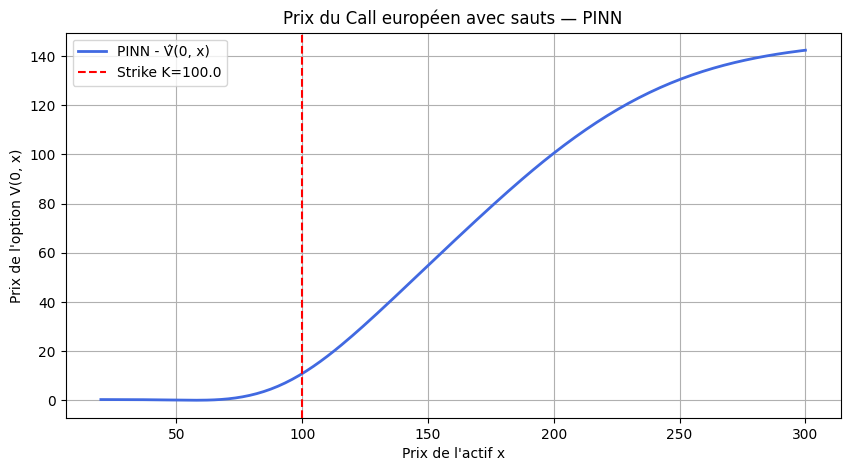

In [35]:
# Grille de visualisation
x_vals = np.linspace(20, 300, 200)
t_val  = 0.0

t_plot = torch.tensor([[t_val]] * 200, dtype=torch.float32).to(device)
x_plot = torch.tensor(x_vals.reshape(-1, 1), dtype=torch.float32).to(device)

with torch.no_grad():
    V_pred = model(t_plot, x_plot).cpu().numpy()

plt.figure(figsize=(10, 5))
plt.plot(x_vals, V_pred, label="PINN - V̂(0, x)", color="royalblue", linewidth=2)
plt.axvline(x=K, color="red", linestyle="--", label=f"Strike K={K}")
plt.xlabel("Prix de l'actif x")
plt.ylabel("Prix de l'option V(0, x)")
plt.title("Prix du Call européen avec sauts — PINN")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    """
    Prix d'un call européen avec la formule de Black-Scholes.
    Retour :
        Prix du call
    """
    # Cas limite : à maturité
    if T <= 1e-10:
        return np.maximum(S - K, 0.0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


In [37]:
from math import exp, factorial

def merton_call(S, K, T, r, sigma, lam, alpha, k_max=50) :
    prix_total = 0.0
    lam_T = lam * T  # paramètre de la loi de Poisson

    for k in range(k_max):

        # Probabilité d'avoir k sauts
        poids = exp(-lam_T) * (lam_T**k) / factorial(k)

        # Volatilité ajustée
        sigma_k = np.sqrt(sigma**2 + k * alpha**2 / T)

        # Prix conditionnel (Black-Scholes)
        prix_bs = black_scholes_call(S, K, T, r, sigma_k)

        # Somme pondérée
        prix_total += poids * prix_bs

    return prix_total

In [38]:
def merton_surface(t_grid, x_grid, K, T, r, sigma, lam, alpha):
    """
    Calcule V(t, x) pour une grille de points.
    """

    V = np.zeros((len(t_grid), len(x_grid)))

    for i, t in enumerate(t_grid):
        tau = T - t

        if tau < 1e-8:
            V[i, :] = np.maximum(x_grid - K, 0.0)
        else:
            for j, x in enumerate(x_grid):
                V[i, j] = merton_call(x, K, tau, r, sigma, lam, alpha)

    return V

In [39]:
def generer_donnees(N, T, K):
    """
    Génère des points (t, x) pour l'entraînement.
    """

    t = np.random.uniform(0, T, N)

    log_x_min = np.log(0.2 * K)
    log_x_max = np.log(3.0 * K)

    x = np.exp(np.random.uniform(log_x_min, log_x_max, N))

    return t, x

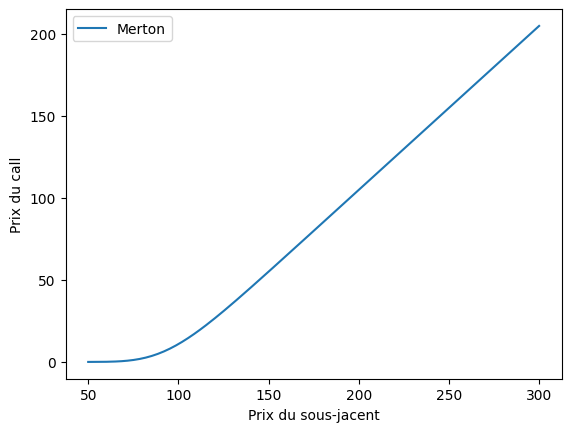

In [40]:

x_vals = np.linspace(50, 300, 150)

V_merton = [merton_call(x, 100, 1, 0.05, 0.2, 0.5, 0.1) for x in x_vals]

plt.plot(x_vals, V_merton, label="Merton")
plt.xlabel("Prix du sous-jacent")
plt.ylabel("Prix du call")
plt.legend()
plt.show()

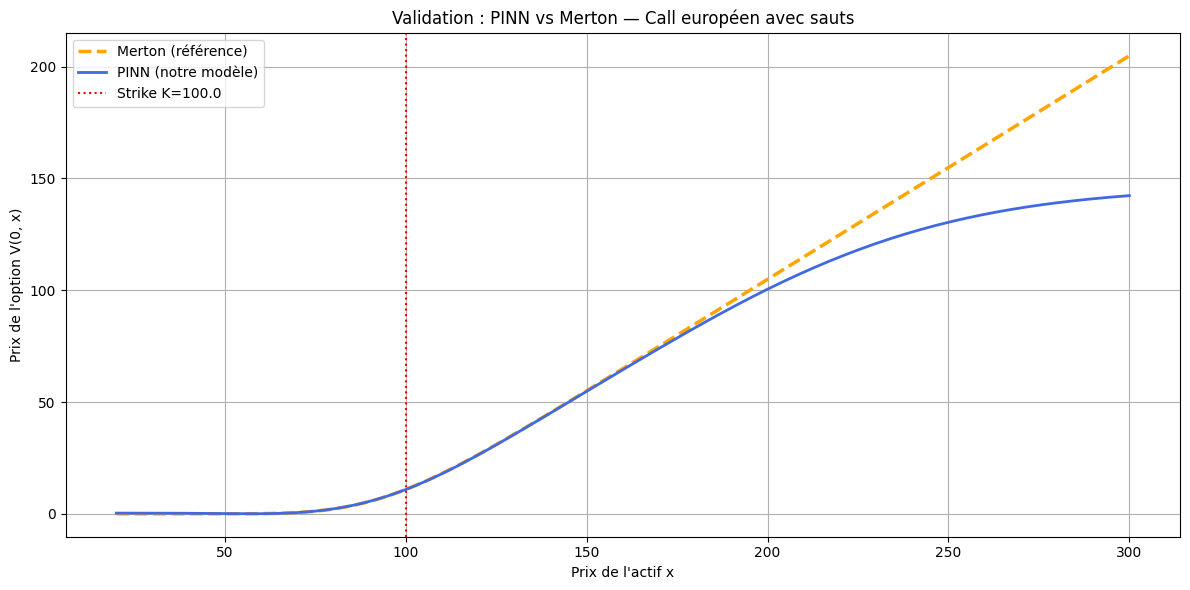

Erreur L2          : 19.6604
Erreur relative    : 25.93%


In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from math import exp, factorial
from scipy.stats import norm

# ── Paramètres communs ────────────────────────────────────
r     = 0.05
sigma = 0.20
alpha = 0.10
lam   = 0.50
K     = 100.0
T     = 1.0

# ── Formule de Merton (code de ton collègue) ─────────────
def black_scholes_call(S, K, T, r, sigma):
    if T <= 1e-10:
        return np.maximum(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def merton_call(S, K, T, r, sigma, lam, alpha, k_max=50):
    prix_total = 0.0
    lam_T = lam * T
    for k in range(k_max):
        poids   = exp(-lam_T) * (lam_T**k) / factorial(k)
        sigma_k = np.sqrt(sigma**2 + k * alpha**2 / T)
        prix_bs = black_scholes_call(S, K, T, r, sigma_k)
        prix_total += poids * prix_bs
    return prix_total

# ── Grille de valeurs x ───────────────────────────────────
x_vals = np.linspace(20, 300, 200)

# ── Courbe Merton (référence analytique) ─────────────────
V_merton = [merton_call(x, K, T, r, sigma, lam, alpha) for x in x_vals]

# ── Courbe PINN (ton modèle) ──────────────────────────────
t_plot = torch.tensor([[0.0]] * 200, dtype=torch.float32).to(device)
x_plot = torch.tensor(x_vals.reshape(-1, 1), dtype=torch.float32).to(device)

with torch.no_grad():
    V_pinn = model(t_plot, x_plot).cpu().numpy().flatten()

# ── Superposition des deux courbes ────────────────────────
plt.figure(figsize=(12, 6))
plt.plot(x_vals, V_merton, label="Merton (référence)",
         color="orange", linewidth=2.5, linestyle="--")
plt.plot(x_vals, V_pinn, label="PINN (notre modèle)",
         color="royalblue", linewidth=2)
plt.axvline(x=K, color="red", linestyle=":", label=f"Strike K={K}")
plt.xlabel("Prix de l'actif x")
plt.ylabel("Prix de l'option V(0, x)")
plt.title("Validation : PINN vs Merton — Call européen avec sauts")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Calcul de l'erreur L2 ─────────────────────────────────
V_merton_arr = np.array(V_merton)
erreur_L2    = np.sqrt(np.mean((V_pinn - V_merton_arr)**2))
erreur_rel   = erreur_L2 / np.mean(V_merton_arr) * 100

print(f"Erreur L2          : {erreur_L2:.4f}")
print(f"Erreur relative    : {erreur_rel:.2f}%")